# 18 — Stress Capital Impact and Adequacy

## What changes when the portfolio is stressed

Only after both approaches and the output floor are complete does the project apply adverse assumptions and recalculate the chain.

Stress can reduce the capital numerator through losses and increase the RWA denominator through PD, LGD, EAD and risk-weight changes.

### How to read the stress results

| Term | Simple meaning |
|---|---|
| Scenario | a defined set of risk shocks rather than a forecast |
| Stress loss | the project loss deduction applied to CET1 |
| CET1 ratio | Common Equity Tier 1 capital divided by final total RWA |
| Headroom | the ratio minus its configured requirement and buffer |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from basel_credit_risk.config import load_all_config
from basel_credit_risk.notebook_support import display, ensure_outputs

CRORE = 10_000_000
COLORS = ["#0B3A53", "#1F77B4", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
configs = load_all_config(ROOT / "config")
ensure_outputs(ROOT)
loans = pd.read_csv(ROOT / "data/processed/current_calculated.csv.gz", low_memory=False)
print(f"Portfolio represented: {len(loans):,} synthetic exposures")

Portfolio represented: 30,000 synthetic exposures


> The capital stack, stress multipliers, add-ons and loss rates are synthetic. The scenario values are not Basel-prescribed; notebook 16 explains how a bank would calibrate them and notebook 14 separates the non-credit RWA inputs.

## Scenario assumptions and recalculated results

PD multipliers, LGD add-ons, collateral shocks and additional drawdowns feed back into loan-level calculations. The table reports the resulting EAD, SA RWA, IRB RWA, expected loss and final total RWA.

In [2]:
scenario_results = pd.read_csv(ROOT / "outputs/tables/scenario_summary.csv").set_index("scenario").reindex(["base", "adverse", "severe"])
money_columns = ["ead", "sa_credit_rwa", "irb_credit_rwa", "expected_loss", "final_total_rwa", "stress_loss"]
scenario_display = scenario_results.copy()
scenario_display[money_columns] /= CRORE
display(scenario_display.rename(columns={column: f"{column} (INR crore)" for column in money_columns}))

,ead (INR crore),sa_credit_rwa (INR crore),irb_credit_rwa (INR crore),expected_loss (INR crore),final_total_rwa (INR crore),floor_binding,stress_loss (INR crore)
scenario,,,,,,,
base,700735.464834,405323.359431,583349.232898,11753.820884,608349.232898,False,0.000000
adverse,746518.283436,438399.649407,769539.139744,16773.183072,794539.139744,False,8958.219401
severe,810207.196957,484304.755279,988975.097136,24945.246357,1013975.097136,False,24306.215909


The scenarios affect more than one output. Greater drawdown raises EAD; weaker credit raises PD and LGD; lower property value can raise mortgage LTV weights and reduce recoveries. These movements increase expected loss and can increase both RWA approaches.

## Capital ratios after the stressed calculation

The chart combines the stressed capital numerator and final RWA denominator. Each dashed threshold includes the configured conservation buffer.

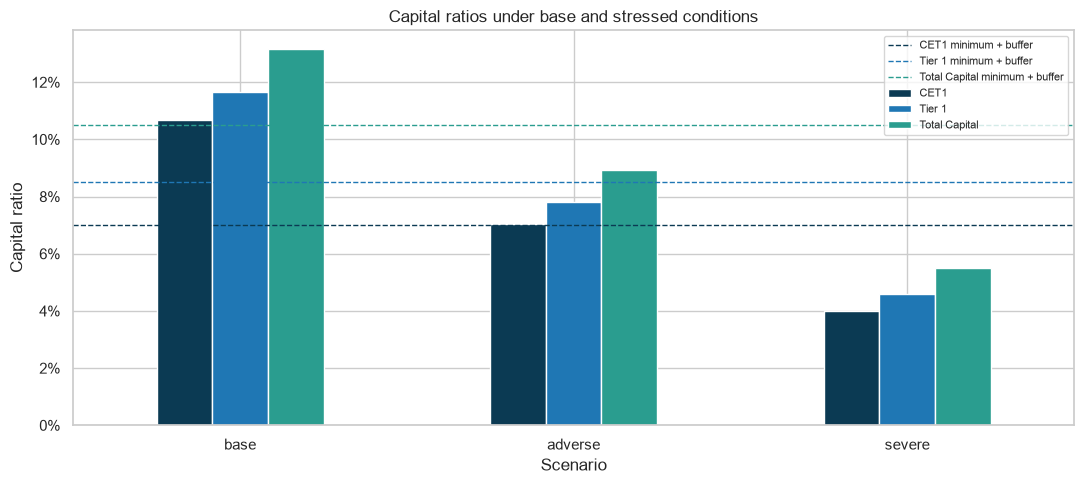

In [3]:
capital = pd.read_csv(ROOT / "outputs/tables/capital_adequacy.csv")
capital_chart = capital.pivot(index="scenario", columns="capital_measure", values="ratio").reindex(["base", "adverse", "severe"])
capital_chart.plot.bar(figsize=(11, 5), color=COLORS[:3], title="Capital ratios under base and stressed conditions")
requirements = capital.groupby("capital_measure")["requirement_plus_buffer"].first()
for colour, measure in zip(COLORS[:3], capital_chart.columns):
    plt.axhline(requirements[measure], color=colour, linestyle="--", linewidth=1,
                label=f"{measure} minimum + buffer")
plt.legend(fontsize=8, loc="upper right")
plt.ylabel("Capital ratio")
plt.xlabel("Scenario")
plt.gca().yaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Falling ratios show less eligible capital for each rupee of RWA. A ratio can decline because capital falls, RWA rises or both occur together. Headroom is therefore calculated against each capital layer's configured threshold.

## Capital amount, RWA and headroom

The table makes the numerator, denominator and resulting headroom visible for CET1, Tier 1 and total capital.

In [4]:
capital_display = capital.copy()
capital_display[["capital_amount", "total_rwa", "stress_loss"]] /= CRORE
display(capital_display.rename(columns={"capital_amount": "Capital (INR crore)", "total_rwa": "Total RWA (INR crore)", "stress_loss": "Stress loss (INR crore)"}))

,scenario,capital_measure,Capital (INR crore),Total RWA (INR crore),ratio,requirement_plus_buffer,headroom,Stress loss (INR crore)
0,base,CET1,65000.000000,608349.232898,0.106847,0.070000,0.036847,0.000000
1,base,Tier 1,71000.000000,608349.232898,0.116709,0.085000,0.031709,0.000000
2,base,Total Capital,80000.000000,608349.232898,0.131503,0.105000,0.026503,0.000000
3,adverse,CET1,56041.780599,794539.139744,0.070534,0.070000,0.000534,8958.219401
4,adverse,Tier 1,62041.780599,794539.139744,0.078085,0.085000,-0.006915,8958.219401
5,adverse,Total Capital,71041.780599,794539.139744,0.089413,0.105000,-0.015587,8958.219401
6,severe,CET1,40693.784091,1013975.097136,0.040133,0.070000,-0.029867,24306.215909
7,severe,Tier 1,46693.784091,1013975.097136,0.046050,0.085000,-0.038950,24306.215909
8,severe,Total Capital,55693.784091,1013975.097136,0.054926,0.105000,-0.050074,24306.215909


The final capital measures now reflect the entire sequence from individual loans through both credit approaches, the output floor and stress effects.